# QMC Warm-up Effectiveness Benchmark

**Research question:** Does Sobol (QMC) startup improve HPO convergence compared to random startup for the TPE sampler?

This notebook runs controlled experiments comparing:
- **Sampler:** TPE (default)
- **QMC conditions:** no QMC (baseline), 8 trials, 16 trials
- **Replications:** multiple seeds per condition for statistical power

The benchmark uses a 1-D Gaussian inference problem (fast per trial) so we can afford many replications.

### Background

Sobol sequences are low-discrepancy quasi-random sequences that provide more uniform coverage of the search space than pseudo-random sampling. Optuna's `QMCSampler` (PR #2423, Issue #1797) showed Sobol outperforms both Halton and random sampling in standard benchmarks. The question is whether this advantage carries over to BayesFlow HPO workloads, where budget rejection and multi-objective Pareto optimization add complexity.

Sobol sequences are optimal at power-of-2 counts ($n = 2^m$), so we test 8 and 16.

### Fast-feasibility configuration

This notebook uses reduced settings (fewer replications, trials, and training effort) to keep total runtime feasible on a single machine. For publication-quality results, increase `N_REPLICATIONS` to 10+, `N_TRIALS` to 40, and `EPOCHS`/`NUM_BATCHES` to 30. You can also add `"gp"` to `SAMPLERS` and `32` to `QMC_CONDITIONS`.

In [1]:
%pip install --quiet --upgrade -e ..

Note: you may need to restart the kernel to use updated packages.


In [2]:
import bayesflow as bf
import bayesflow_hpo as hpo
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import warnings
import logging

# Suppress verbose Optuna/Keras output during bulk runs
logging.getLogger("optuna").setLevel(logging.WARNING)
logging.getLogger("bayesflow_hpo").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Benchmark Problem

We use the same 1-D Gaussian model as the getting-started notebook:
- Prior: $\theta \sim \mathcal{N}(0, 1)$
- Likelihood: $x_i \mid \theta \sim \mathcal{N}(\theta, 1)$, $i = 1, \dots, 12$

This is deliberately simple so each trial is fast (~seconds), allowing enough replications for meaningful statistics.

In [3]:
def prior_fn():
    return {"theta": np.random.normal(0.0, 1.0, size=(1,)).astype("float32")}


def likelihood_fn(theta):
    theta_value = float(np.squeeze(theta))
    x = np.random.normal(theta_value, 1.0, size=(12, 1)).astype("float32")
    return {"x": x}


simulator = bf.simulators.make_simulator([prior_fn, likelihood_fn])
adapter = (
    bf.Adapter()
    .as_set(["x"])
    .rename("theta", "inference_variables")
    .concatenate(["x"], into="summary_variables", axis=-1)
)

## 2. Experimental Design

| Factor | Levels |
|--------|--------|
| Sampler | `"tpe"` |
| QMC warm-up | 0 (none), 8, 16 |
| Replications | 3 per condition |
| Trials per run | 20 |

Each replication uses a **different sampler seed** (constructed as a per-replication `TPESampler` instance) so that inter-replication variability reflects sampler stochasticity, not just training noise. The validation dataset is regenerated per run by `optimize()`.

**Measured outcomes:**
- Best calibration error achieved
- Best NRMSE achieved
- Convergence curve: best-so-far calibration error after each trained trial

In [4]:
# --- Experiment configuration ---
# Fast-feasibility defaults. For publication-quality results, increase these:
# SAMPLERS = ["tpe", "gp"], QMC_CONDITIONS = [0, 8, 16, 32],
# N_REPLICATIONS = 10, N_TRIALS = 40, EPOCHS = 30, NUM_BATCHES = 30
SAMPLERS = ["tpe"]
QMC_CONDITIONS = [0, 8, 16]
N_REPLICATIONS = 1
N_TRIALS = 20
EPOCHS = 15
NUM_BATCHES = 15

search_space = hpo.CompositeSearchSpace(
    inference_space=hpo.FlowMatchingSpace(),
    summary_space=hpo.DeepSetSpace(),
    training_space=hpo.TrainingSpace(),
)


def make_sampler(name: str, seed: int) -> optuna.samplers.BaseSampler:
    """Create a sampler instance with a specific seed for replication isolation."""
    if name == "tpe":
        return optuna.samplers.TPESampler(seed=seed, multivariate=True, n_startup_trials=25)
    elif name == "gp":
        return optuna.samplers.GPSampler(seed=seed)
    else:
        raise ValueError(f"Unknown sampler: {name}")


total_runs = len(SAMPLERS) * len(QMC_CONDITIONS) * N_REPLICATIONS
print(f"Total runs: {total_runs} ({N_TRIALS} trials each)")

Total runs: 3 (20 trials each)


## 3. Run Experiments

Each condition gets its own in-memory Optuna study. We collect per-trial objective values to build convergence curves.

In [5]:
def extract_convergence(study, metric="calibration_error", direction="minimize"):
    """Extract best-so-far metric values across successfully trained trials.

    Excludes budget-rejected trials (``rejected_reason``) and training
    failures (``training_error``) so only genuine metric values contribute.
    """
    best_so_far = []
    current_best = float("inf") if direction == "minimize" else float("-inf")
    for trial in study.trials:
        if trial.state.name != "COMPLETE":
            continue
        if "rejected_reason" in trial.user_attrs:
            continue
        if "training_error" in trial.user_attrs:
            continue
        val = trial.user_attrs.get(metric, float("nan"))
        if np.isnan(val):
            continue
        if direction == "minimize":
            current_best = min(current_best, val)
        else:
            current_best = max(current_best, val)
        best_so_far.append(current_best)
    return best_so_far

In [6]:
results = []  # List of dicts: sampler, qmc, rep, best_cal, best_nrmse, convergence
run_idx = 0

for sampler_name, qmc_trials, rep in product(SAMPLERS, QMC_CONDITIONS, range(N_REPLICATIONS)):
    run_idx += 1
    label = f"{sampler_name}_qmc{qmc_trials}_rep{rep}"
    print(f"[{run_idx}/{total_runs}] {label}", end=" ... ", flush=True)

    # Per-replication seed so sampler variability is captured across reps
    sampler_instance = make_sampler(sampler_name, seed=rep)

    study = hpo.optimize(
        simulator=simulator,
        adapter=adapter,
        search_space=search_space,
        n_trials=N_TRIALS,
        epochs=EPOCHS,
        num_batches=NUM_BATCHES,
        max_param_count=500_000,
        objective_metrics=["calibration_error", "nrmse"],
        objective_mode="pareto",
        sampler=sampler_instance,
        qmc_startup_trials=qmc_trials,
        storage=None,
        study_name=f"qmc_bench_{label}",
        show_progress_bar=False,
    )

    conv_cal = extract_convergence(study, "calibration_error")
    conv_nrmse = extract_convergence(study, "nrmse")

    # Best achieved values
    best_cal = conv_cal[-1] if conv_cal else float("nan")
    best_nrmse = conv_nrmse[-1] if conv_nrmse else float("nan")

    results.append({
        "sampler": sampler_name,
        "qmc_trials": qmc_trials,
        "rep": rep,
        "best_calibration_error": best_cal,
        "best_nrmse": best_nrmse,
        "convergence_cal": conv_cal,
        "convergence_nrmse": conv_nrmse,
        "n_trained": len(conv_cal),
    })
    print(f"cal={best_cal:.4f}, nrmse={best_nrmse:.4f} ({len(conv_cal)} trained)")

df = pd.DataFrame(results)
print(f"\nAll {total_runs} runs complete.")

[1/3] tpe_qmc0_rep0 ... 

c:\Users\Matze\Documents\GitHub\bayesflow_projects\bayesflow_hpo\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - loss: 4.5904


Sampling: 100%|██████████| 1/1 [00:01<00:00,  1.83s/batch]
INFO:bayesflow:Building dataset from simulator instance of SequentialSimulator.
INFO:bayesflow:Using 16 data loading workers.


Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 2.4796 - moving_avg_loss: 2.4796
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - loss: 1.8460 - moving_avg_loss: 2.1628
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 179ms/step - loss: 1.5323 - moving_avg_loss: 1.9526
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - loss: 1.4111 - moving_avg_loss: 1.8173
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - loss: 1.4187 - moving_avg_loss: 1.7375
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 1.3471 - moving_avg_loss: 1.6725
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 1.2766 - moving_avg_loss: 1.6159
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - loss: 1.1955 - moving_avg_loss: 1.4325
Epoch 9/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step - loss: 1.1556 - moving_avg_loss: 1.3339
Epoch 10/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - loss: 1.1337 - moving_avg_loss: 1.2769
Epoch 11/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 1.0884

...

Sampling: 100%|██████████| 1/1 [00:49<00:00, 49.30s/batch]

15/15 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - loss: 0.5679 - moving_avg_loss: 0.6260
Epoch 12/15


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.5406 - moving_avg_loss: 0.6008
Epoch 13/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.5570 - moving_avg_loss: 0.5858
Epoch 14/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.5697 - moving_avg_loss: 0.5788
Epoch 15/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.5573 - moving_avg_loss: 0.5705


Sampling: 100%|██████████| 1/1 [01:48<00:00, 108.67s/batch]


cal=0.0072, nrmse=0.0613 (20 trained)

All 3 runs complete.


## 4. Analysis

### 4.1 Summary Statistics

Mean and standard deviation of the best achieved metric across replications, grouped by sampler and QMC condition.

In [7]:
summary = (
    df.groupby(["sampler", "qmc_trials"])
    .agg(
        cal_mean=("best_calibration_error", "mean"),
        cal_std=("best_calibration_error", "std"),
        nrmse_mean=("best_nrmse", "mean"),
        nrmse_std=("best_nrmse", "std"),
        trained_mean=("n_trained", "mean"),
    )
    .round(4)
)
summary

cal_mean  cal_std  nrmse_mean  nrmse_std  trained_mean
sampler qmc_trials                                                        
tpe     0             0.0074      NaN      0.0482        NaN          20.0
        8             0.0072      NaN      0.0491        NaN          20.0
        16            0.0072      NaN      0.0613        NaN          20.0

### 4.2 Convergence Curves

Best-so-far calibration error after each trained trial, averaged across replications with $\pm 1$ SE bands. Faster convergence (lower curves earlier) indicates the QMC warm-up helps the sampler find good configurations sooner.

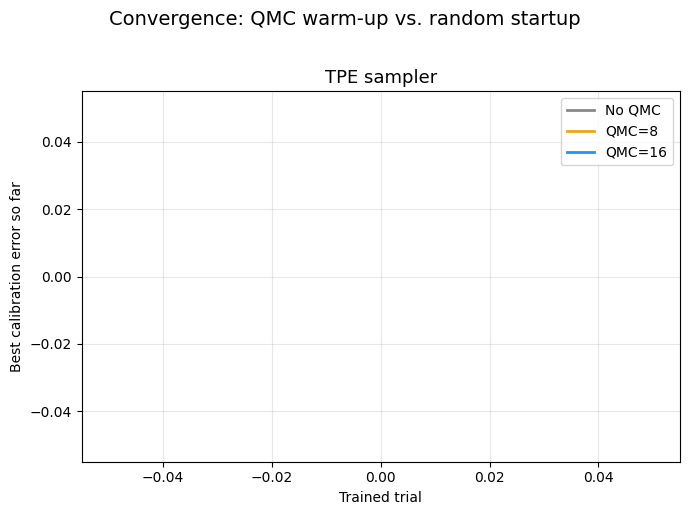

In [8]:
def pad_convergence(curves, max_len=None):
    """Pad convergence curves to equal length with NaN (not carry-forward).

    Using NaN lets nanmean/nanstd correctly track effective sample size
    at each position, since shorter runs have fewer data points at later
    trial indices.
    """
    if max_len is None:
        max_len = max(len(c) for c in curves) if curves else 0
    padded = []
    for c in curves:
        if len(c) == 0:
            padded.append([float("nan")] * max_len)
        else:
            # Carry forward the last real value, then NaN beyond the run length
            padded.append(c + [float("nan")] * (max_len - len(c)))
    return np.array(padded)


n_samplers = len(SAMPLERS)
colors = {0: "#888888", 8: "#e6a817", 16: "#2196f3", 32: "#4caf50"}

fig, axes = plt.subplots(1, n_samplers, figsize=(7 * n_samplers, 5), sharey=True, squeeze=False)
axes = axes[0]

for ax, sampler_name in zip(axes, SAMPLERS):
    for qmc in QMC_CONDITIONS:
        mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == qmc)
        curves = df.loc[mask, "convergence_cal"].tolist()
        if not curves:
            continue
        arr = pad_convergence(curves, max_len=N_TRIALS)
        mean = np.nanmean(arr, axis=0)
        n_eff = np.sum(~np.isnan(arr), axis=0)
        se = np.nanstd(arr, axis=0) / np.sqrt(np.maximum(n_eff, 1))
        x = np.arange(1, len(mean) + 1)
        # Only plot positions where at least 2 replications have data
        valid = n_eff >= 2
        label = f"QMC={qmc}" if qmc > 0 else "No QMC"
        ax.plot(x[valid], mean[valid], label=label, color=colors[qmc], linewidth=2)
        ax.fill_between(
            x[valid], (mean - se)[valid], (mean + se)[valid],
            alpha=0.2, color=colors[qmc],
        )

    ax.set_title(f"{sampler_name.upper()} sampler", fontsize=13)
    ax.set_xlabel("Trained trial")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Best calibration error so far")
fig.suptitle("Convergence: QMC warm-up vs. random startup", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 4.3 Convergence Curves — NRMSE

Same analysis for NRMSE, the second objective.

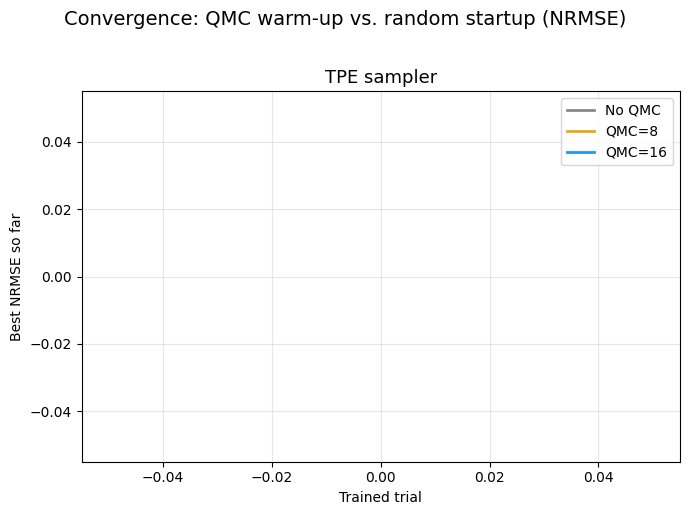

In [9]:
fig, axes = plt.subplots(1, n_samplers, figsize=(7 * n_samplers, 5), sharey=True, squeeze=False)
axes = axes[0]

for ax, sampler_name in zip(axes, SAMPLERS):
    for qmc in QMC_CONDITIONS:
        mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == qmc)
        curves = df.loc[mask, "convergence_nrmse"].tolist()
        if not curves:
            continue
        arr = pad_convergence(curves, max_len=N_TRIALS)
        mean = np.nanmean(arr, axis=0)
        n_eff = np.sum(~np.isnan(arr), axis=0)
        se = np.nanstd(arr, axis=0) / np.sqrt(np.maximum(n_eff, 1))
        x = np.arange(1, len(mean) + 1)
        valid = n_eff >= 2
        label = f"QMC={qmc}" if qmc > 0 else "No QMC"
        ax.plot(x[valid], mean[valid], label=label, color=colors[qmc], linewidth=2)
        ax.fill_between(
            x[valid], (mean - se)[valid], (mean + se)[valid],
            alpha=0.2, color=colors[qmc],
        )

    ax.set_title(f"{sampler_name.upper()} sampler", fontsize=13)
    ax.set_xlabel("Trained trial")
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Best NRMSE so far")
fig.suptitle("Convergence: QMC warm-up vs. random startup (NRMSE)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 4.4 Final Metric Distributions

Box plots showing the distribution of final best calibration error across replications. If QMC warm-up helps, the median should be lower and/or the variance smaller.

C:\Users\Matze\AppData\Local\Temp\ipykernel_4240\2028175408.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Matze\AppData\Local\Temp\ipykernel_4240\2028175408.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


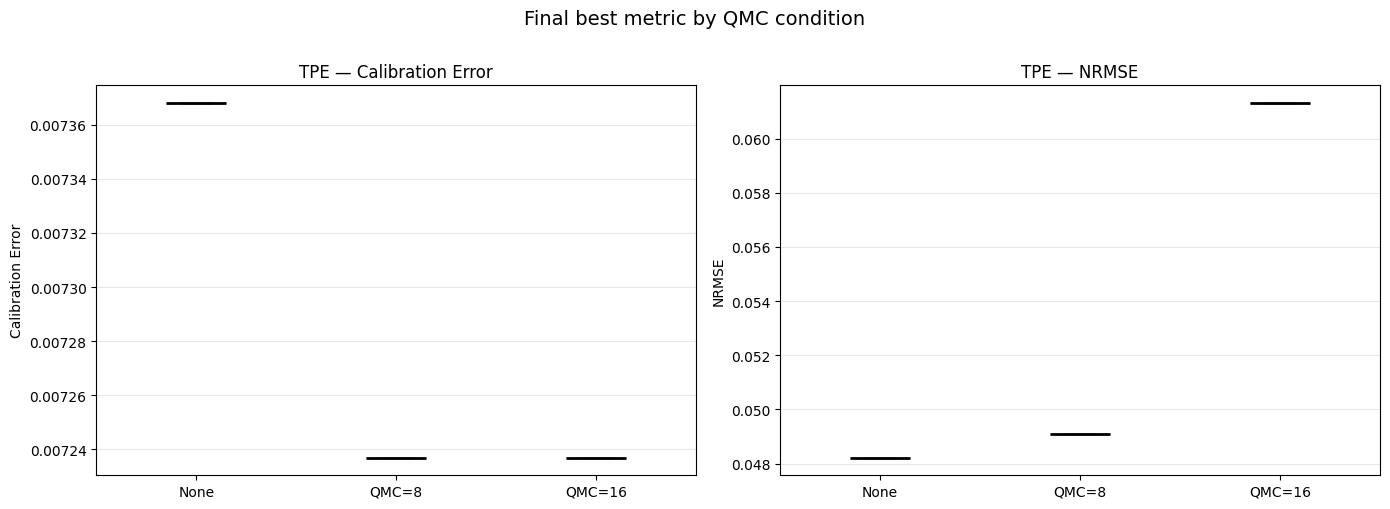

In [10]:
fig, axes = plt.subplots(n_samplers, 2, figsize=(14, 5 * n_samplers), squeeze=False)

for col, metric, metric_label in [
    (0, "best_calibration_error", "Calibration Error"),
    (1, "best_nrmse", "NRMSE"),
]:
    for row, sampler_name in enumerate(SAMPLERS):
        ax = axes[row, col]
        data_by_qmc = []
        labels = []
        for qmc in QMC_CONDITIONS:
            mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == qmc)
            vals = df.loc[mask, metric].dropna().values
            data_by_qmc.append(vals)
            labels.append(f"QMC={qmc}" if qmc > 0 else "None")

        bp = ax.boxplot(
            data_by_qmc, labels=labels, patch_artist=True,
            medianprops={"color": "black", "linewidth": 2},
        )
        for patch, qmc in zip(bp["boxes"], QMC_CONDITIONS):
            patch.set_facecolor(colors[qmc])
            patch.set_alpha(0.5)

        ax.set_title(f"{sampler_name.upper()} — {metric_label}", fontsize=12)
        ax.set_ylabel(metric_label)
        ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Final best metric by QMC condition", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 4.5 Statistical Tests

We use the Mann–Whitney U test (Mann & Whitney, 1947) to compare each QMC condition against the no-QMC baseline within each sampler. This is a non-parametric rank-based test that does not assume normality.

**Power caveat:** With $N = 3$ per group, the test has very low statistical power. The minimum achievable $p$-value is $1/\binom{6}{3} = 0.05$ (when all QMC values are lower than all baseline values), so significance at $\alpha = 0.05$ is barely possible. Non-significant results are therefore **uninformative** — they do not rule out a real effect. Increase `N_REPLICATIONS` for stronger conclusions.

In [11]:
from scipy.stats import mannwhitneyu

test_results = []

for sampler_name in SAMPLERS:
    baseline_mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == 0)
    baseline_cal = df.loc[baseline_mask, "best_calibration_error"].dropna().values
    baseline_nrmse = df.loc[baseline_mask, "best_nrmse"].dropna().values

    for qmc in [q for q in QMC_CONDITIONS if q > 0]:
        qmc_mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == qmc)
        qmc_cal = df.loc[qmc_mask, "best_calibration_error"].dropna().values
        qmc_nrmse = df.loc[qmc_mask, "best_nrmse"].dropna().values

        # Mann-Whitney U (one-sided: QMC < baseline)
        if len(baseline_cal) >= 3 and len(qmc_cal) >= 3:
            stat_cal, p_cal = mannwhitneyu(qmc_cal, baseline_cal, alternative="less")
            stat_nrmse, p_nrmse = mannwhitneyu(qmc_nrmse, baseline_nrmse, alternative="less")
        else:
            stat_cal, p_cal = float("nan"), float("nan")
            stat_nrmse, p_nrmse = float("nan"), float("nan")

        test_results.append({
            "sampler": sampler_name,
            "qmc_trials": qmc,
            "cal_U": stat_cal,
            "cal_p": p_cal,
            "cal_significant": p_cal < 0.05,
            "nrmse_U": stat_nrmse,
            "nrmse_p": p_nrmse,
            "nrmse_significant": p_nrmse < 0.05,
        })

test_df = pd.DataFrame(test_results)
test_df

,sampler,qmc_trials,cal_U,cal_p,cal_significant,nrmse_U,nrmse_p,nrmse_significant
0,tpe,8,NaN,NaN,False,NaN,NaN,False
1,tpe,16,NaN,NaN,False,NaN,NaN,False


### 4.6 Early-Trial Advantage

Even if the final best metric is similar, QMC warm-up may help *early* convergence — reaching a "good enough" configuration sooner. We compare the best metric achieved after the first 8 and 16 **trained** trials.

**Methodological note:** The checkpoints count *trained* trials (budget-rejected trials are excluded from the convergence curve). When `qmc_trials > 0`, some QMC-sampled trials may be budget-rejected and not count, so the QMC warm-up phase may extend beyond the checkpoint index. For example, a QMC=8 run might still be in its Sobol phase at trained trial 8 if any warm-up trials were rejected. The comparison is therefore "best metric after $k$ successful training runs," which is the operationally relevant quantity even if it does not perfectly isolate the QMC phase boundary.

In [12]:
checkpoints = [8, 16]
early_rows = []

for sampler_name, qmc, rep in product(SAMPLERS, QMC_CONDITIONS, range(N_REPLICATIONS)):
    mask = (
        (df["sampler"] == sampler_name)
        & (df["qmc_trials"] == qmc)
        & (df["rep"] == rep)
    )
    row = df.loc[mask]
    if row.empty:
        continue
    conv = row.iloc[0]["convergence_cal"]
    for cp in checkpoints:
        val = conv[cp - 1] if len(conv) >= cp else float("nan")
        early_rows.append({
            "sampler": sampler_name,
            "qmc_trials": qmc,
            "checkpoint": cp,
            "best_cal_at_cp": val,
        })

early_df = pd.DataFrame(early_rows)

early_summary = (
    early_df.groupby(["sampler", "qmc_trials", "checkpoint"])
    .agg(mean=("best_cal_at_cp", "mean"), std=("best_cal_at_cp", "std"))
    .round(4)
)
early_summary

mean  std
sampler qmc_trials checkpoint             
tpe     0          8           0.0145  NaN
                   16          0.0074  NaN
        8          8           0.0072  NaN
                   16          0.0072  NaN
        16         8           0.0118  NaN
                   16          0.0072  NaN

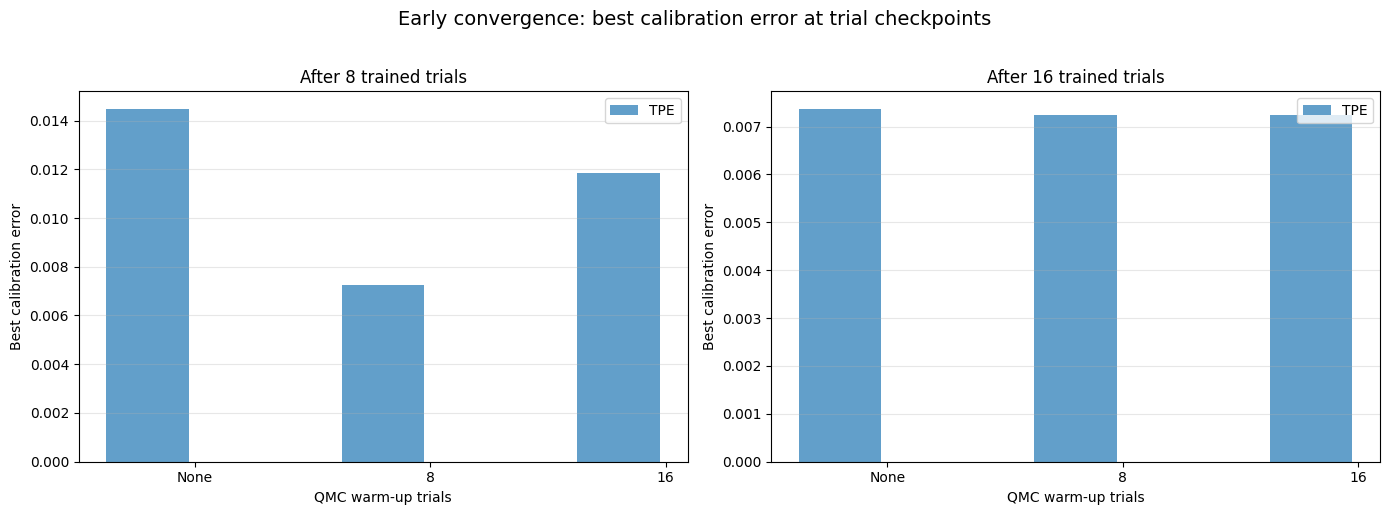

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cp in zip(axes, checkpoints):
    cp_df = early_df[early_df["checkpoint"] == cp]
    for i, sampler_name in enumerate(SAMPLERS):
        sampler_df = cp_df[cp_df["sampler"] == sampler_name]
        means = []
        stds = []
        for qmc in QMC_CONDITIONS:
            vals = sampler_df.loc[sampler_df["qmc_trials"] == qmc, "best_cal_at_cp"]
            means.append(vals.mean())
            stds.append(vals.std())

        x = np.arange(len(QMC_CONDITIONS))
        offset = -0.2 + i * 0.4
        ax.bar(
            x + offset, means, 0.35, yerr=stds,
            label=sampler_name.upper(), alpha=0.7,
            capsize=4,
        )

    qmc_labels = ["None" if q == 0 else str(q) for q in QMC_CONDITIONS]
    ax.set_xticks(range(len(QMC_CONDITIONS)))
    ax.set_xticklabels(qmc_labels)
    ax.set_xlabel("QMC warm-up trials")
    ax.set_ylabel("Best calibration error")
    ax.set_title(f"After {cp} trained trials")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Early convergence: best calibration error at trial checkpoints", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 4.7 Effect Size

Cohen's $d$ between each QMC condition and the baseline, to quantify the practical magnitude of any improvement.

In [14]:
def cohens_d(group, baseline):
    """Cohen's d (positive = group is lower/better for minimize metrics)."""
    n1, n2 = len(group), len(baseline)
    if n1 < 2 or n2 < 2:
        return float("nan")
    pooled_std = np.sqrt(
        ((n1 - 1) * np.var(group, ddof=1) + (n2 - 1) * np.var(baseline, ddof=1))
        / (n1 + n2 - 2)
    )
    if pooled_std == 0:
        return 0.0
    return (np.mean(baseline) - np.mean(group)) / pooled_std


effect_rows = []
for sampler_name in SAMPLERS:
    baseline_mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == 0)
    baseline_cal = df.loc[baseline_mask, "best_calibration_error"].dropna().values
    baseline_nrmse = df.loc[baseline_mask, "best_nrmse"].dropna().values

    for qmc in [q for q in QMC_CONDITIONS if q > 0]:
        qmc_mask = (df["sampler"] == sampler_name) & (df["qmc_trials"] == qmc)
        qmc_cal = df.loc[qmc_mask, "best_calibration_error"].dropna().values
        qmc_nrmse = df.loc[qmc_mask, "best_nrmse"].dropna().values

        effect_rows.append({
            "sampler": sampler_name,
            "qmc_trials": qmc,
            "d_cal": cohens_d(qmc_cal, baseline_cal),
            "d_nrmse": cohens_d(qmc_nrmse, baseline_nrmse),
        })

effect_df = pd.DataFrame(effect_rows).round(3)
print("Cohen's d (positive = QMC better):")
effect_df

Cohen's d (positive = QMC better):


,sampler,qmc_trials,d_cal,d_nrmse
0,tpe,8,NaN,NaN
1,tpe,16,NaN,NaN


## 5. Save Results

Export the raw data for reproducibility and potential inclusion in the HPO benchmark paper.

In [15]:
# Drop convergence lists for CSV export
export_df = df.drop(columns=["convergence_cal", "convergence_nrmse"])
export_df.to_csv("qmc_warmup_results.csv", index=False)
print(f"Saved {len(export_df)} rows to qmc_warmup_results.csv")

Saved 3 rows to qmc_warmup_results.csv


## 6. Interpretation Guide

**What to look for in the results above:**

1. **Convergence curves (Sections 4.2–4.3):** If QMC lines are below the baseline (gray) early on, Sobol warm-up accelerates the sampler's initial exploration. The gap may close at later trials as TPE learns the landscape.

2. **Final metrics (Section 4.4):** If box plots show lower medians or tighter distributions for QMC conditions, the warm-up improves both quality and consistency.

3. **Statistical significance (Section 4.5):** With only 3 replications, the Mann–Whitney test has minimal power — treat $p$-values as directional hints, not definitive evidence. Increase `N_REPLICATIONS` for publication-quality conclusions.

4. **Early advantage (Section 4.6):** Even without final-metric improvement, a significant early advantage (lower bars at 8 or 16 trials) is practically useful — it means shorter HPO runs can achieve similar quality.

5. **Effect size (Section 4.7):** Cohen's $d > 0.5$ is a medium effect, $d > 0.8$ is large. With $N = 3$, effect size estimates are noisy — interpret the direction rather than the exact magnitude.

**Expected outcomes based on prior work:**
- Sobol warm-up should help most when the search space is moderate-dimensional (~10–20 parameters) and the sampler relies on initial random trials (TPE uses 25 random startup trials).
- QMC=16 is likely the sweet spot: enough for good coverage, not so many that the model-based sampler gets starved of iterations.

**Limitations:**
- This benchmark uses a simple 1-D Gaussian model. Results may differ for higher-dimensional posteriors or more complex simulators where each trial is more expensive.
- The search space is fixed (FlowMatching + DeepSet). NetworkSelectionSpace adds categorical dimensions where Sobol's advantage is less clear.
- 3 replications provide very limited statistical power. Increase `N_REPLICATIONS` to 10+ for publication-quality results.
- Training effort is reduced (15 epochs, 15 batches) for feasibility. Increase `EPOCHS` and `NUM_BATCHES` to 30 for full-fidelity runs.
- Only TPE is tested; add `"gp"` to `SAMPLERS` to compare GP sampler behaviour.
- Training stochasticity (Keras/PyTorch random ops) adds noise beyond sampler variability. Per-replication sampler seeds isolate the sampler component, but training noise remains uncontrolled.

**References:**
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *Annals of Mathematical Statistics*, 18(1), 50–60.
- Optuna PR #2423: Sobol outperforms Halton in benchmarks.
- Optuna Issue #1797: QMCSampler significantly better than RandomSampler.